# Lab 5 — NYSE Multi-Cluster View

**Day 05 · Unsupervised Learning · Cisco AI/ML Training**

---

Visual compare: partitioning clusters (K-Means) vs density clusters (DBSCAN).

**Dataset:** `data/nyse/nyse_stocks.csv` (500 rows, 25 symbols)

## Why this matters <!-- cisco-doc-enrich-2026 -->

Comparing **k=2,3,4 side by side** builds judgment — financial features rarely form perfect
spheres; narrative beats a single arbitrary k.

```
same features  -->  k=2 (macro sectors)  |  k=3  |  k=4 (finer themes)
```


## Setup and dual-model inference

In [1]:
%matplotlib inline

from pathlib import Path

GH_ROOT = Path.cwd().resolve()
if GH_ROOT.name == "notebooks":
    GH_ROOT = GH_ROOT.parents[2]
elif (GH_ROOT.parent / "notebooks").is_dir() and (GH_ROOT.parents[1] / "requirements-student.txt").is_file():
    GH_ROOT = GH_ROOT.parents[1]
else:
    for parent in [GH_ROOT, *GH_ROOT.parents]:
        if (parent / "requirements-student.txt").is_file():
            GH_ROOT = parent
            break

**Step 2** — run the cell below and read the printed summary. <!-- cisco-split-debug-2026 -->

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display
from sklearn.cluster import DBSCAN, KMeans
from sklearn.preprocessing import StandardScaler

OUTPUT_DIR = GH_ROOT / "hands-on" / "05-unsupervised-learning" / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FEATURE_COLUMNS = ["avg_close", "volatility", "avg_volume", "avg_range"]

**Step 3** — run the cell below and read the printed summary. <!-- cisco-split-debug-2026 -->

In [3]:
nyse = pd.read_csv(GH_ROOT / "data" / "nyse" / "nyse_stocks.csv", parse_dates=["date"])
nyse["range"] = nyse["high"] - nyse["low"]
features = (
    nyse.groupby("symbol")
    .agg(
        avg_close=("close", "mean"),
        volatility=("close", "std"),
        avg_volume=("volume", "mean"),
        avg_range=("range", "mean"),
    )
    .reset_index()
)
features["volatility"] = features["volatility"].fillna(0.0)

X_scaled = StandardScaler().fit_transform(features[FEATURE_COLUMNS])

kmeans_labels = KMeans(n_clusters=4, random_state=42, n_init=10).fit_predict(X_scaled)
dbscan_labels = DBSCAN(eps=1.2, min_samples=3).fit_predict(X_scaled)

features = features.copy()
features["kmeans"] = kmeans_labels
features["dbscan"] = dbscan_labels

print(f"symbols plotted: {len(features)}")

symbols plotted: 25


## Cluster counts from both methods

In [4]:
kmeans_counts = dict(zip(*np.unique(kmeans_labels, return_counts=True)))
dbscan_counts = dict(zip(*np.unique(dbscan_labels, return_counts=True)))

print("Lab 5 — NYSE multi-cluster view")
print(f"K-Means cluster counts: {kmeans_counts}")
print(f"DBSCAN cluster counts: {dbscan_counts}")


Lab 5 — NYSE multi-cluster view
K-Means cluster counts: {np.int32(0): np.int64(8), np.int32(1): np.int64(9), np.int32(2): np.int64(7), np.int32(3): np.int64(1)}
DBSCAN cluster counts: {np.int64(-1): np.int64(11), np.int64(0): np.int64(6), np.int64(1): np.int64(4), np.int64(2): np.int64(4)}


## Side-by-side cluster plots

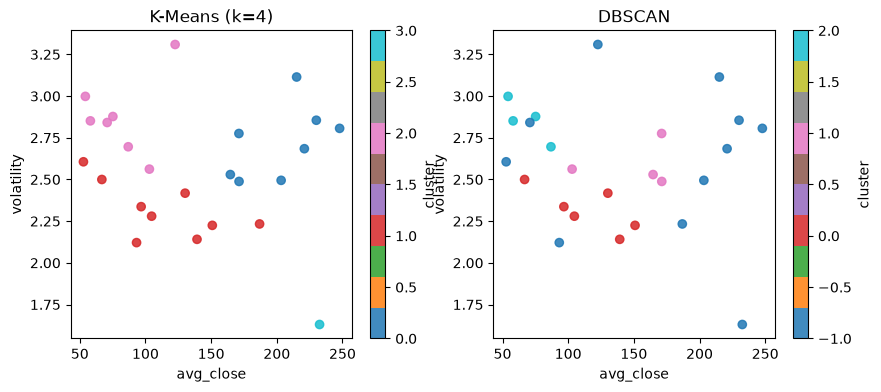

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, labels, title in zip(
    axes,
    [kmeans_labels, dbscan_labels],
    ["K-Means (k=4)", "DBSCAN"],
    strict=True,
):
    scatter = ax.scatter(
        features["avg_close"],
        features["volatility"],
        c=labels,
        cmap="tab10",
        alpha=0.85,
    )
    ax.set_xlabel("avg_close")
    ax.set_ylabel("volatility")
    ax.set_title(title)
    fig.colorbar(scatter, ax=ax, label="cluster")

**Step 2** — run the cell below and read the printed summary. <!-- cisco-split-debug-2026 -->

In [6]:
fig.tight_layout()
plot_path = OUTPUT_DIR / "multi_cluster_view.png"
fig.savefig(plot_path, dpi=100)
plt.show()

print(f"plot saved: {plot_path.name}")
print(f"full path: {plot_path}")

plot saved: multi_cluster_view.png
full path: C:\25-Trainings\2-Confirmed\10-June-26-AI-ML-Cisco\GH\hands-on\05-unsupervised-learning\output\multi_cluster_view.png


## Inspect DBSCAN noise points

In [7]:
noise = features.loc[features["dbscan"] == -1, ["symbol", "avg_close", "volatility"]]
display(noise.sort_values("volatility").round(2))
print(f"noise count: {len(noise)}")


,symbol,avg_close,volatility
16,PEP,232.55,1.63
11,MA,93.21,2.12
0,AAPL,186.88,2.23
4,DIS,203.29,2.49
1,AMZN,52.76,2.61
14,NFLX,220.97,2.68
21,V,247.82,2.81
24,XOM,70.84,2.84
19,TSLA,230.07,2.86
13,MSFT,215.09,3.11


noise count: 11


## Agreement/disagreement table

In [8]:
features["agree"] = features["kmeans"] == features["dbscan"]
disagree = features.loc[~features["agree"] | (features["dbscan"] == -1),
                      ["symbol", "kmeans", "dbscan"]]
display(disagree.sort_values("dbscan"))


,symbol,kmeans,dbscan
0,AAPL,1,-1
1,AMZN,1,-1
5,GOOGL,2,-1
4,DIS,0,-1
14,NFLX,0,-1
16,PEP,3,-1
13,MSFT,0,-1
11,MA,1,-1
21,V,0,-1
24,XOM,2,-1


## Render saved plot preview

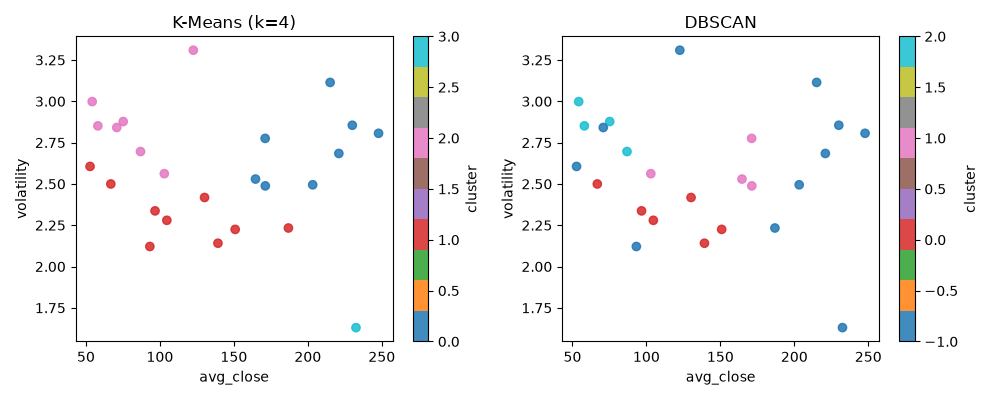

In [9]:
if plot_path.is_file():
    display(Image(filename=str(plot_path)))
else:
    print("Run the plot cell above first.")


### Visualization prompt 1

Show all symbols with both labels.

In [10]:
display(features[['symbol','kmeans','dbscan']].sort_values(['kmeans','dbscan','symbol']))

,symbol,kmeans,dbscan
4,DIS,0,-1
13,MSFT,0,-1
14,NFLX,0,-1
19,TSLA,0,-1
21,V,0,-1
3,CSCO,0,1
15,NVDA,0,1
22,VZ,0,1
0,AAPL,1,-1
1,AMZN,1,-1


### Visualization prompt 2

Compute simple agreement rate.

In [11]:
print(round((features['kmeans']==features['dbscan']).mean(), 3))

0.16


### Visualization prompt 3

Agreement rate excluding noise.

In [12]:
mask = features['dbscan']!=-1; print(round((features.loc[mask,'kmeans']==features.loc[mask,'dbscan']).mean(), 3))

0.286

### Visualization prompt 4

Top avg_close by K-Means cluster.

In [13]:
display(features.sort_values('avg_close', ascending=False).groupby('kmeans').head(2)[['symbol','kmeans','avg_close']].round(2))

# cisco-debug-summary
print("Groupby complete — compare categories in the table above.")

,symbol,kmeans,avg_close
21,V,0,247.82
16,PEP,3,232.55
19,TSLA,0,230.07
0,AAPL,1,186.88
23,WMT,1,150.89
5,GOOGL,2,122.58
12,META,2,102.98


Groupby complete — compare categories in the table above.


### Visualization prompt 5

Top volatility by DBSCAN label.

In [14]:
display(features.sort_values('volatility', ascending=False).groupby('dbscan').head(2)[['symbol','dbscan','volatility']].round(3))

# cisco-debug-summary
print("Groupby complete — compare categories in the table above.")

,symbol,dbscan,volatility
5,GOOGL,-1,3.309
13,MSFT,-1,3.114
8,JNJ,2,2.998
20,UNH,2,2.877
22,VZ,1,2.776
12,META,1,2.562
18,PG,0,2.500
2,BAC,0,2.418


Groupby complete — compare categories in the table above.


### Visualization prompt 6

Cross-tab of label overlap.

In [15]:
display(pd.crosstab(features['kmeans'], features['dbscan']))

dbscan,-1,0,1,2
kmeans,,,,
0,5,0,3,0
1,3,6,0,0
2,2,0,1,4
3,1,0,0,0


### Visualization prompt 7

List noise symbols only.

In [16]:
print(features.loc[features['dbscan']==-1, 'symbol'].tolist())

['AAPL', 'AMZN', 'DIS', 'GOOGL', 'MA', 'MSFT', 'NFLX', 'PEP', 'TSLA', 'V', 'XOM']


### Visualization prompt 8

Check plot file metadata.

In [17]:
print({'exists': plot_path.is_file(), 'size_bytes': plot_path.stat().st_size if plot_path.is_file() else 0})

{'exists': True, 'size_bytes': 45881}

### Visualization prompt 9

Summarize counts in one dict.

In [18]:
print({'kmeans': kmeans_counts, 'dbscan': dbscan_counts})

{'kmeans': {np.int32(0): np.int64(8), np.int32(1): np.int64(9), np.int32(2): np.int64(7), np.int32(3): np.int64(1)}, 'dbscan': {np.int64(-1): np.int64(11), np.int64(0): np.int64(6), np.int64(1): np.int64(4), np.int64(2): np.int64(4)}}


### Visualization prompt 10

Mean feature values for disagreements.

In [19]:
display(features.loc[(features['kmeans']!=features['dbscan']) | (features['dbscan']==-1)].groupby('dbscan')[FEATURE_COLUMNS].mean().round(2))

# cisco-debug-summary
print("Groupby complete — compare categories in the table above.")

,avg_close,volatility,avg_volume,avg_range
dbscan,,,,
-1,170.55,2.61,24537715.07,2.83
0,114.75,2.32,27094811.46,2.73
1,152.50,2.59,22804049.69,3.02


Groupby complete — compare categories in the table above.


### Visualization prompt 11

Sort disagreement table by symbol.

In [20]:
display(disagree.sort_values('symbol'))

,symbol,kmeans,dbscan
0,AAPL,1,-1
1,AMZN,1,-1
2,BAC,1,0
3,CSCO,0,1
4,DIS,0,-1
5,GOOGL,2,-1
6,HD,1,0
7,INTC,1,0
10,KO,1,0
11,MA,1,-1


### Visualization prompt 12

How many symbols in each K-Means cluster?

In [21]:
print(features['kmeans'].value_counts().sort_index().to_dict())

# cisco-debug-summary
print("Value counts — long tail categories may be omitted.")

{0: 8, 1: 9, 2: 7, 3: 1}


Value counts — long tail categories may be omitted.


### Visualization prompt 13

How many symbols in each DBSCAN label?

In [22]:
print(features['dbscan'].value_counts().sort_index().to_dict())

# cisco-debug-summary
print("Value counts — long tail categories may be omitted.")

{-1: 11, 0: 6, 1: 4, 2: 4}
Value counts — long tail categories may be omitted.


### Visualization prompt 14

Plot compact agreement bar.

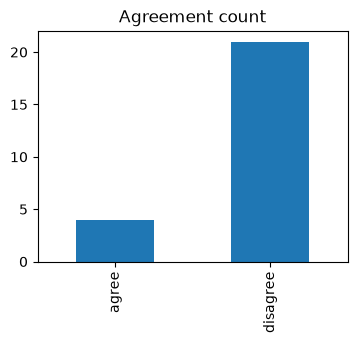

In [23]:
pd.Series({'agree': int(features['agree'].sum()), 'disagree': int((~features['agree']).sum())}).plot(kind='bar', figsize=(4,3), title='Agreement count');

### Visualization prompt 15

Verify all 25 symbols are unique.

In [24]:
print(features['symbol'].nunique(), len(features))

25 25


### Visualization prompt 16

Inspect symbols in singleton K-Means cluster 3.

In [25]:
display(features.loc[features['kmeans']==3, ['symbol','avg_close','volatility']].round(2))

,symbol,avg_close,volatility
16,PEP,232.55,1.63


### Visualization prompt 17

Inspect DBSCAN label 2 members.

In [26]:
display(features.loc[features['dbscan']==2, ['symbol','avg_close','volatility']].round(2))

,symbol,avg_close,volatility
8,JNJ,54.23,3.00
9,JPM,86.88,2.70
17,PFE,58.06,2.85
20,UNH,75.19,2.88


### Visualization prompt 18

Bridge to segmentation summary.

In [27]:
print('Next: convert cluster IDs into segment narratives and summaries.')

Next: convert cluster IDs into segment narratives and summaries.


### Visualization prompt 19

Check cluster means by algorithm.

In [28]:
display(features.groupby('kmeans')[FEATURE_COLUMNS].mean().round(2))

# cisco-debug-summary
print("Groupby complete — compare categories in the table above.")

,avg_close,volatility,avg_volume,avg_range
kmeans,,,,
0,203.03,2.72,23941634.18,3.04
1,113.49,2.32,26739334.61,2.70
2,81.54,2.88,25411128.95,2.93
3,232.55,1.63,19338890.65,2.58


Groupby complete — compare categories in the table above.


### Visualization prompt 20

Quick final visualization note.

In [29]:
print('Keep the saved PNG for slide-ready cluster comparison.')

Keep the saved PNG for slide-ready cluster comparison.


### Lab 5 quick recap 1

Pause and summarize one takeaway from the previous cell before moving on.

In [30]:
print("Lab 5 recap step 1: completed")

Lab 5 recap step 1: completed


### Lab 5 quick recap 2

Pause and summarize one takeaway from the previous cell before moving on.

In [31]:
print("Lab 5 recap step 2: completed")

Lab 5 recap step 2: completed


### Lab 5 quick recap 3

Pause and summarize one takeaway from the previous cell before moving on.

In [32]:
print("Lab 5 recap step 3: completed")

Lab 5 recap step 3: completed


### Lab 5 quick recap 4

Pause and summarize one takeaway from the previous cell before moving on.

In [33]:
print("Lab 5 recap step 4: completed")

Lab 5 recap step 4: completed


## Final checkpoint

In [34]:
assert len(features) == 25
assert plot_path.is_file()
assert kmeans_counts == {0: 8, 1: 9, 2: 7, 3: 1}
assert dbscan_counts[-1] == 11
assert dbscan_counts[0] == 6 and dbscan_counts[1] == 4 and dbscan_counts[2] == 4
print("Numbers match — you're good.")



Numbers match — you're good.


## Reflection

When should teams present both partitioning and density views together?